<a href="https://colab.research.google.com/github/kalyani-n2711/Delhi-AQI-Analysis-ML/blob/main/delhi_AQI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

!curl -o '/content/delhi not null.csv' https://files.catbox.moe/u1w9qp.csv

file_path = '/content/delhi not null.csv'
df = pd.read_csv(file_path)
df.head()


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 62.0M  100 62.0M    0     0  34.0M      0  0:00:01  0:00:01 --:--:-- 34.0M


,Unnamed: 0,StationId,Datetime,PM2.5,PM10,NO2,CO,SO2,O3,AQI,StationName,Day_period,Month,Year,Season,AQ_Acceptability,AQI_Bucket
0,859196,31,2015-04-05 02:00:00,79.83,130.00,54.52,0.27,11.70,80.33,399.0,"R K Puram, Delhi - DPCC",4,4,2015,2,Unacceptable,Very Poor
1,859197,31,2015-04-05 03:00:00,74.50,91.50,51.88,0.37,10.62,82.75,359.0,"R K Puram, Delhi - DPCC",4,4,2015,2,Unacceptable,Very Poor
2,859198,31,2015-04-05 04:00:00,51.17,96.83,41.86,0.18,9.00,84.33,359.0,"R K Puram, Delhi - DPCC",1,4,2015,2,Unacceptable,Very Poor
3,14356,2,2015-04-05 05:00:00,106.83,318.17,46.76,1.49,3.53,13.32,148.0,"Anand Vihar, Delhi - DPCC",1,4,2015,2,Unacceptable,Moderate
4,859199,31,2015-04-05 05:00:00,41.83,78.50,24.02,0.10,3.49,85.75,359.0,"R K Puram, Delhi - DPCC",1,4,2015,2,Unacceptable,Very Poor


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: KMeans with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Step 2: PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Step 3: Visualize PCA with KMeans clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='Set1', data=df)
plt.title('PCA Visualization with KMeans Clusters (k=2)')
plt.show()


NameError: name 'X_scaled' is not defined

In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.cm as cm


In [ ]:
kmeans_labels = df['KMeans_Cluster'].values  # From your code
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score for KMeans (k=2): {sil_score:.2f}")


KeyError: 'KMeans_Cluster'

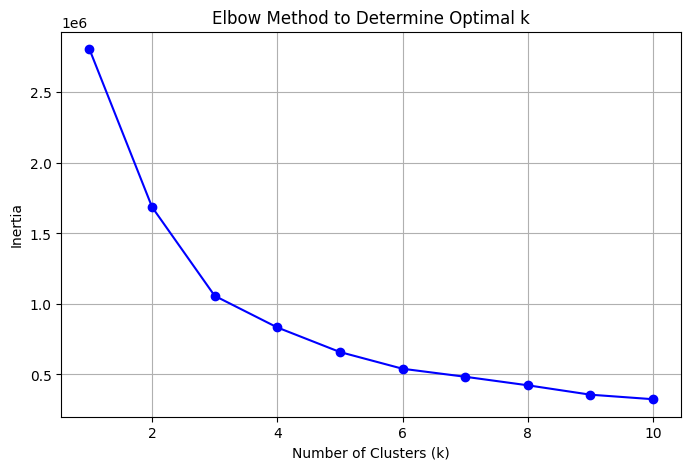

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# 2. Find optimal k using Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# 3. Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Determine Optimal k')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 1: Select relevant numeric features for t-SNE
features = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
X = df[features]

# STEP 2: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 3: Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# STEP 4: Add t-SNE results to the DataFrame
df['TSNE1'] = X_tsne[:, 0]
df['TSNE2'] = X_tsne[:, 1]

# STEP 5: Visualize t-SNE by AQI_Bucket
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='AQI_Bucket', palette='tab10', s=60)
plt.title('t-SNE Projection of Air Quality Data by AQI Category')
plt.grid(True)
plt.legend(title='AQI Bucket', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
# Suppose you forced 6 clusters (k=6) with KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Create a custom label map (you can change the mapping order based on your observation)
cluster_to_aqi = {
    0: 'Moderate',
    1: 'Severe',
    2: 'Poor',
    3: 'Very Poor',
    4: 'Satisfactory',
    5: 'Good'
}

# Map numeric clusters to AQI labels
df['Cluster_Label'] = df['KMeans_Cluster'].map(cluster_to_aqi)


In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster_Label', palette='Set2', s=60)
plt.title('PCA Projection with KMeans Clusters Labeled as AQI Categories')
plt.legend(title='Cluster (Named)')
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC # Import SVC here, though not strictly needed for fixing the NameError, it's in the source cell


# Assuming df is already loaded and preprocessed from previous steps
# If not, you need to load and preprocess it here, including handling missing values

# For demonstration, let's assume df exists and has 'AQI', 'AQ_Acceptability'
# And the necessary features from previous cells like 'StationName', 'Day_period', 'Season'
# We will recreate the relevant parts of the preprocessing for clarity.

# This part should align with how the data was prepared for the other classifiers
# Drop rows with missing target or label columns
# It's important to use the df created in previous steps, not reload it here
# Let's assume 'df' from previous steps (after cleaning outliers etc.) is available.
# If 'Day_period' and 'Season' are not yet created, ensure the cells creating them
# run before this one. For instance, you might need to add:
# df['Datetime'] = pd.to_datetime(df['Datetime'])
# df['Month'] = df['Datetime'].dt.month
# df['Hour'] = df['Datetime'].dt.hour
# def get_season(month):
#     if month in [12, 1, 2]: return 'Winter'
#     elif month in [3, 4, 5]: return 'Spring'
#     elif month in [6, 7, 8]: return 'Summer'
#     elif month in [9, 10, 11]: return 'Autumn'
# df['Season'] = df['Month'].apply(get_season)
# def get_day_period(hour):
#     if 5 <= hour < 12: return 'Morning'
#     elif 12 <= hour < 17: return 'Afternoon'
#     elif 17 <= hour < 21: return 'Evening'
#     else: return 'Night'
# df['Day_period'] = df['Hour'].apply(get_day_period)


# Assuming df exists and has 'StationName', 'Day_period', 'Season', 'AQ_Acceptability', and numeric columns like PM2.5 etc.
# Drop rows with missing target or required feature columns
df_classification = df.copy() # Create a copy to avoid modifying the original df used for other analysis
df_classification = df_classification.dropna(subset=['AQI', 'AQ_Acceptability', 'StationName', 'Day_period', 'Season'])

label_cols = ['StationName', 'Day_period', 'Season', 'AQ_Acceptability']
label_encoders = {}
le = None # Initialize le to None
for col in label_cols:
    # Check if column exists before applying LabelEncoder
    if col in df_classification.columns:
        le_temp = LabelEncoder()
        df_classification[col] = le_temp.fit_transform(df_classification[col])
        label_encoders[col] = le_temp
        if col == 'AQ_Acceptability':
            le = le_temp # Keep the label encoder for the target variable
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping encoding.")


# Define features (X) and target (y) for classification
# Ensure 'Datetime', 'AQI_Bucket', and 'AQI' are not used as features for classification
features_for_classification = [col for col in df_classification.columns if col not in ['AQI', 'AQ_Acceptability', 'Datetime', 'AQI_Bucket', 'Month', 'Year', 'Hour']] # Exclude time components and original AQI columns
X = df_classification[features_for_classification]
y = df_classification['AQ_Acceptability']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data for classification
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize accuracies dictionary (assuming it was used elsewhere to store results)
# Or create it here if it's the first time using it
if 'accuracies' not in globals():
    accuracies = {}

# Now you can proceed with training your models in subsequent cells
# For example, the Logistic Regression training cell can now run without NameError
# svm = SVC(kernel='linear', random_state=42) # This line is part of the original SVM cell
# svm.fit(X_train_scaled, y_train)
# ... rest of the SVM code

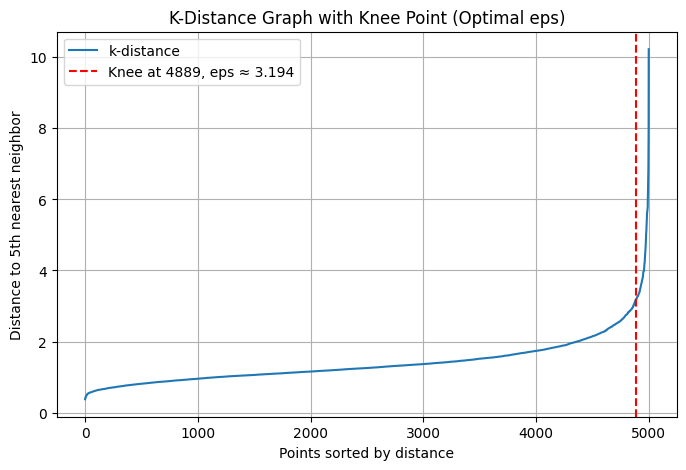

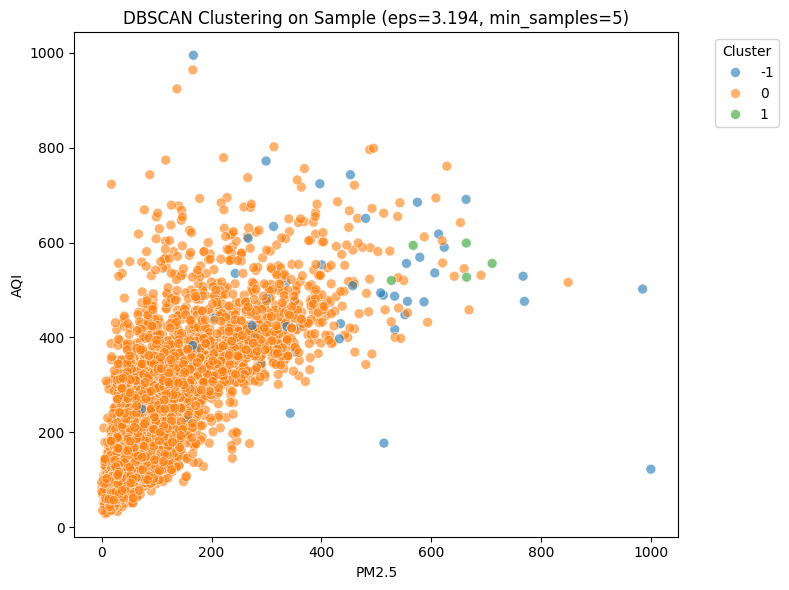

In [ ]:
!pip install kneed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from kneed import KneeLocator

# Step 0: Sample data to reduce RAM usage
sample_size = 5000
df_sample = df.sample(n=sample_size, random_state=42)

# Step 1: Scale numeric features from the sample
X_sample = df_sample.select_dtypes(include=np.number)
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# Step 2: Compute k-distance graph
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_sample_scaled)
distances, _ = neighbors_fit.kneighbors(X_sample_scaled)
distances = np.sort(distances[:, min_samples - 1])

# Step 3: Automatically find the elbow (knee) point as optimal eps
knee = KneeLocator(range(1, len(distances)+1), distances, curve='convex', direction='increasing')
eps_value = distances[knee.knee] if knee.knee is not None else 0.3  # fallback value

# Plot K-distance graph with detected knee
plt.figure(figsize=(8, 5))
plt.plot(distances, label='k-distance')
plt.axvline(knee.knee, color='r', linestyle='--', label=f"Knee at {knee.knee}, eps ≈ {eps_value:.3f}")
plt.title("K-Distance Graph with Knee Point (Optimal eps)")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.legend()
plt.grid(True)
plt.show()

# Step 4: Run DBSCAN with detected eps
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_sample_scaled)
df_sample['DBSCAN_Cluster'] = dbscan_labels

# Step 5: Visualize clustering with less overlap (opacity + point size)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PM2.5', y='AQI', hue='DBSCAN_Cluster',
    data=df_sample, palette='tab10', legend='full',
    alpha=0.6, s=50  # reduce size to avoid overlap
)
plt.title(f'DBSCAN Clustering on Sample (eps={eps_value:.3f}, min_samples={min_samples})')
plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
print(df['StationName'].unique())


['R K Puram, Delhi - DPCC' 'Anand Vihar, Delhi - DPCC'
 'Punjabi Bagh, Delhi - DPCC' 'Mandir Marg, Delhi - DPCC'
 'Rohini, Delhi - DPCC' 'Okhla Phase-2, Delhi - DPCC'
 'Wazirpur, Delhi - DPCC'
 'Major Dhyan Chand National Stadium, Delhi - DPCC'
 'Jawaharlal Nehru Stadium, Delhi - DPCC' 'Ashok Vihar, Delhi - DPCC'
 'Dwarka-Sector 8, Delhi - DPCC' 'Najafgarh, Delhi - DPCC'
 'Narela, Delhi - DPCC' 'Nehru Nagar, Delhi - DPCC'
 'Patparganj, Delhi - DPCC' 'Jahangirpuri, Delhi - DPCC'
 'Vivek Vihar, Delhi - DPCC' 'Sonia Vihar, Delhi - DPCC'
 'Dr. Karni Singh Shooting Range, Delhi - DPCC' 'DTU, Delhi - CPCB'
 'Sirifort, Delhi - CPCB' 'ITO, Delhi - CPCB' 'Pusa, Delhi - DPCC'
 'Sri Aurobindo Marg, Delhi - DPCC' 'Mundka, Delhi - DPCC'
 'Bawana, Delhi - DPCC' 'Alipur, Delhi - DPCC']


In [ ]:

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy: {test_acc:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
cm = confusion_matrix(y_test, y_test_pred)
disp = Confusion


In [ ]:
df['StationName_clean'] = df['StationName'].str.split(',').str[0].str.strip().str.lower()


Buffered data was truncated after reaching the output size limit.

In [ ]:
print(df.shape)
print(df.info())

# Summary statistics
print(df.describe())

(496539, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496539 entries, 0 to 496538
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        496539 non-null  int64  
 1   StationId         496539 non-null  int64  
 2   Datetime          496539 non-null  object 
 3   PM2.5             496539 non-null  float64
 4   PM10              496539 non-null  float64
 5   NO2               496539 non-null  float64
 6   CO                496539 non-null  float64
 7   SO2               496539 non-null  float64
 8   O3                496539 non-null  float64
 9   AQI               496539 non-null  float64
 10  StationName       496539 non-null  object 
 11  Day_period        496539 non-null  int64  
 12  Month             496539 non-null  int64  
 13  Year              496539 non-null  int64  
 14  Season            496539 non-null  int64  
 15  AQ_Acceptability  496539 non-null  object 
 16  AQI_Buc

Series([], dtype: int64)


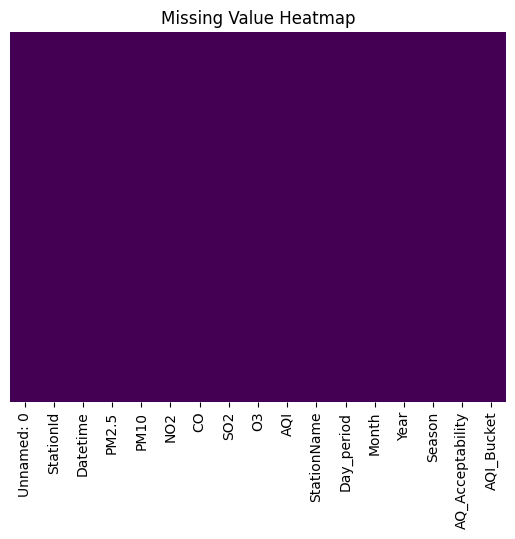

In [ ]:
# Check missing values
missing = df.isnull().sum()
print(missing[missing > 0])

# Visualize missing data
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()


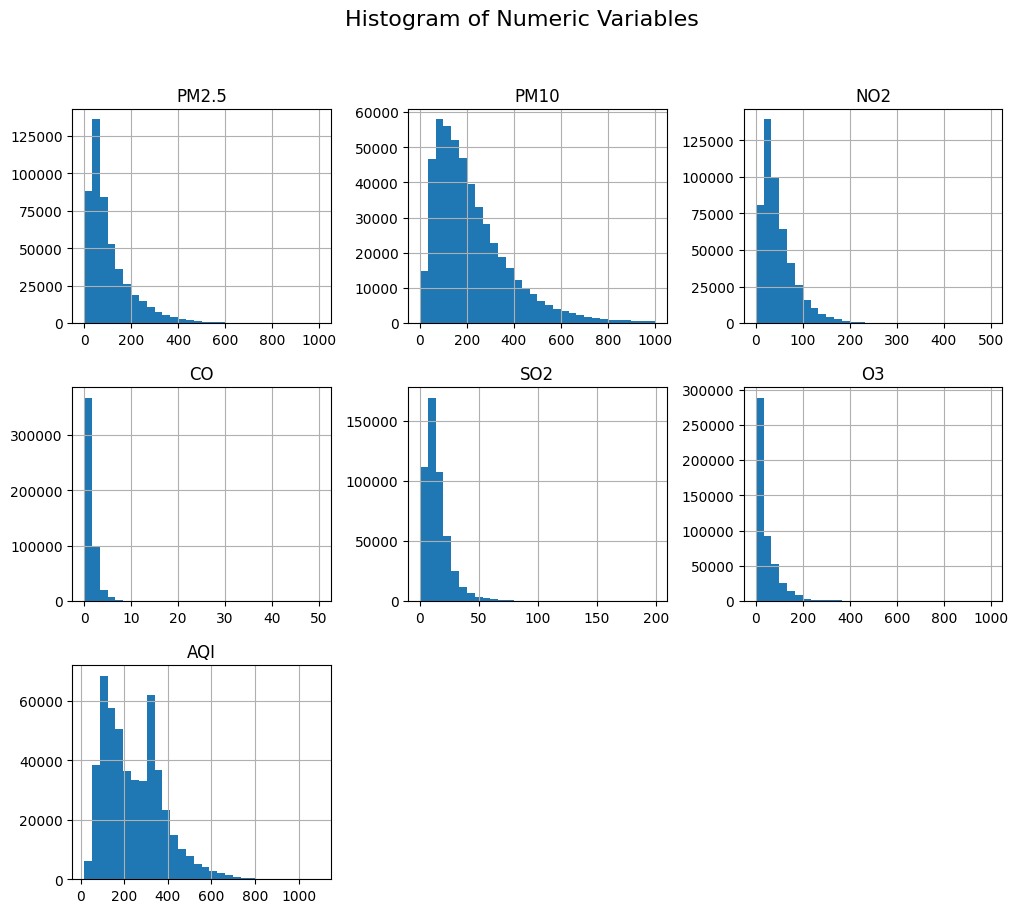

In [ ]:
numerics = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
df[numerics].hist(figsize=(12, 10), bins=30)
plt.suptitle('Histogram of Numeric Variables', fontsize=16)
plt.show()


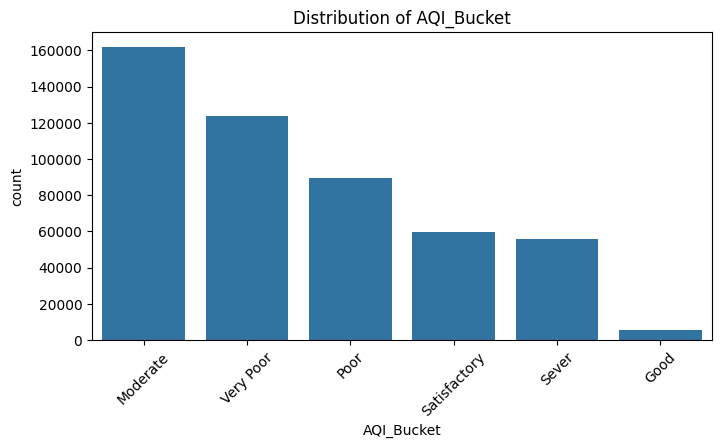

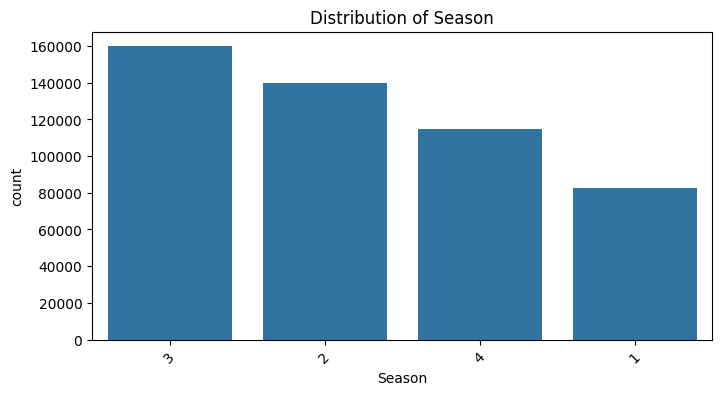

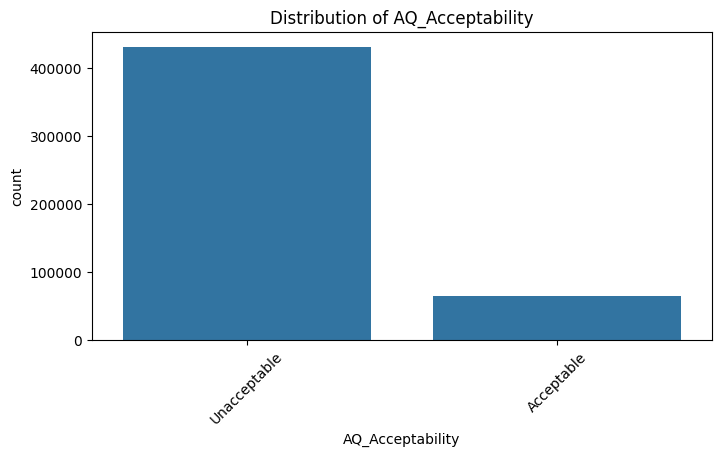

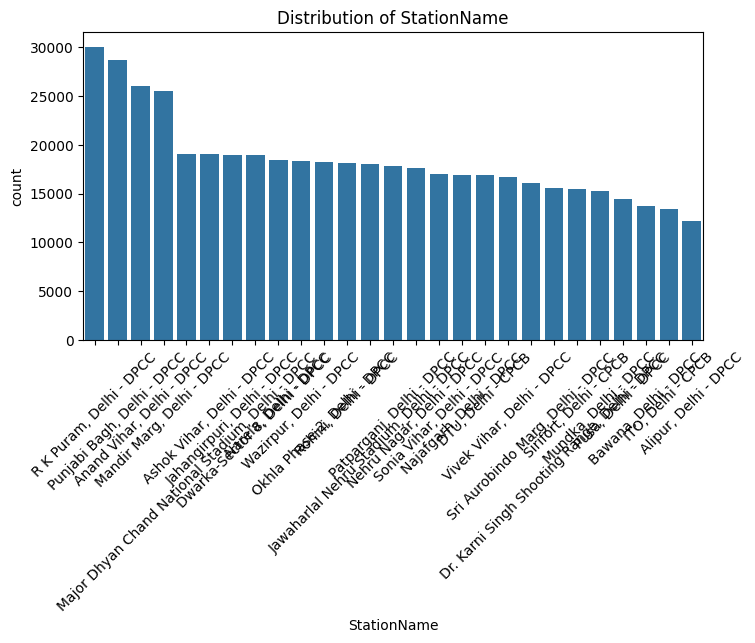

In [ ]:
categoricals = ['AQI_Bucket', 'Season', 'AQ_Acceptability', 'StationName']
for cat in categoricals:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=cat, order=df[cat].value_counts().index)
    plt.title(f'Distribution of {cat}')
    plt.xticks(rotation=45)
    plt.show()


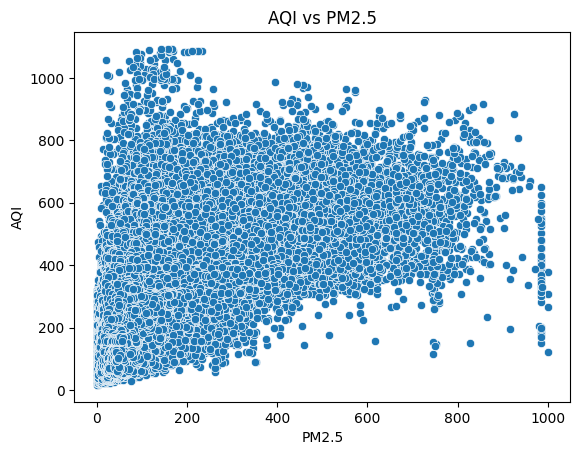

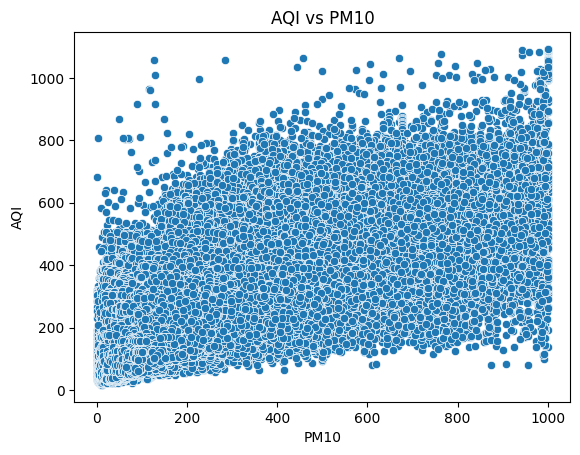

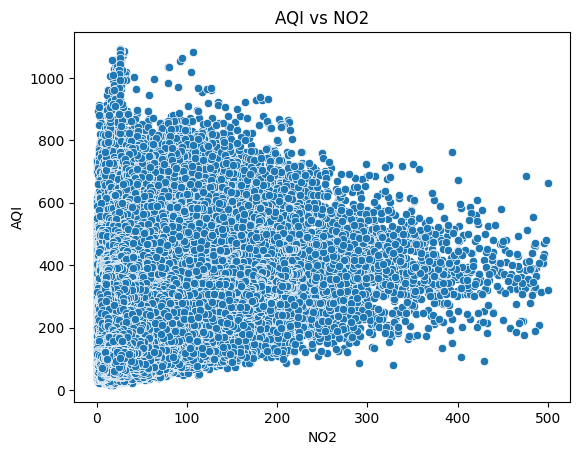

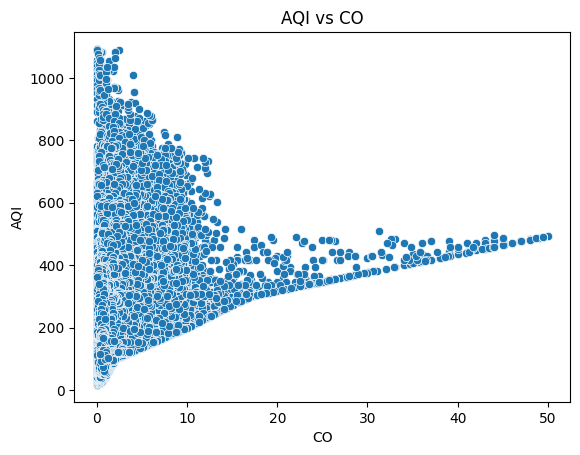

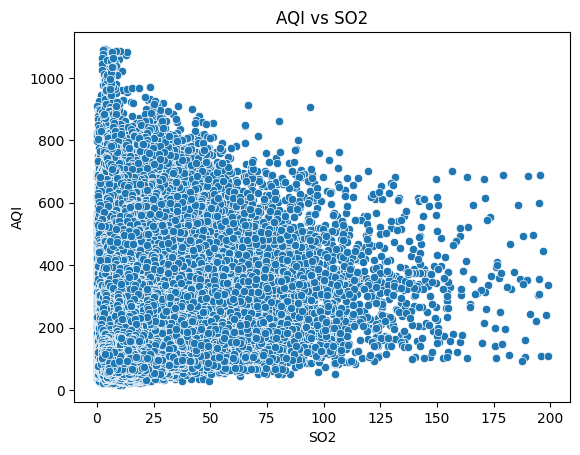

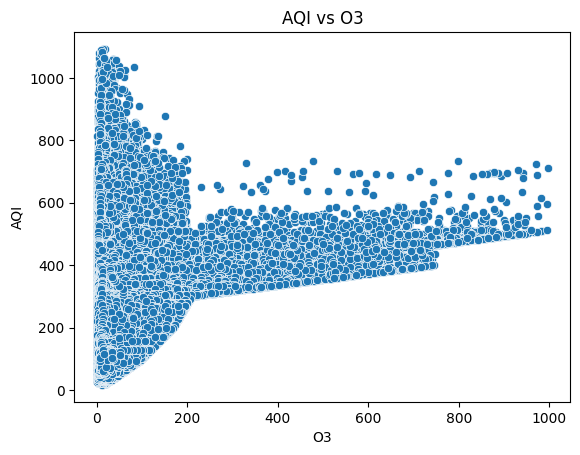

In [ ]:
for col in ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']:
    sns.scatterplot(data=df, x=col, y='AQI')
    plt.title(f'AQI vs {col}')
    plt.show()


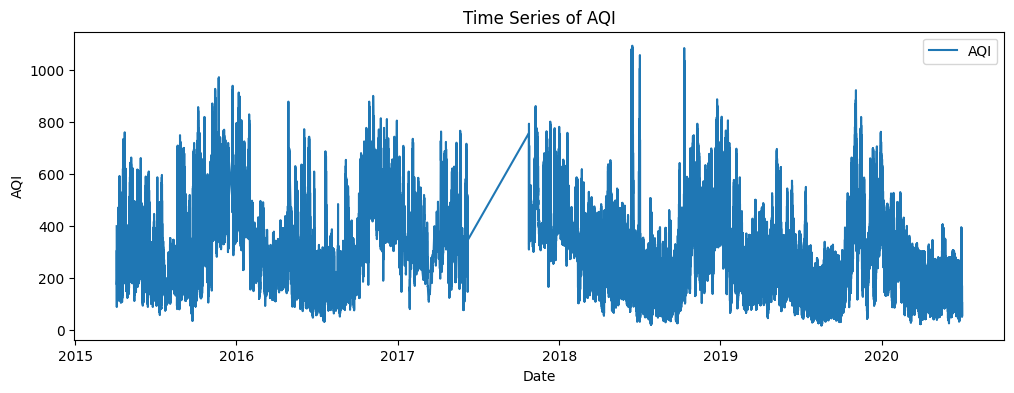

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

plt.figure(figsize=(12, 4))
plt.plot(df['Datetime'], df['AQI'], label='AQI')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('Time Series of AQI')
plt.legend()
plt.show()


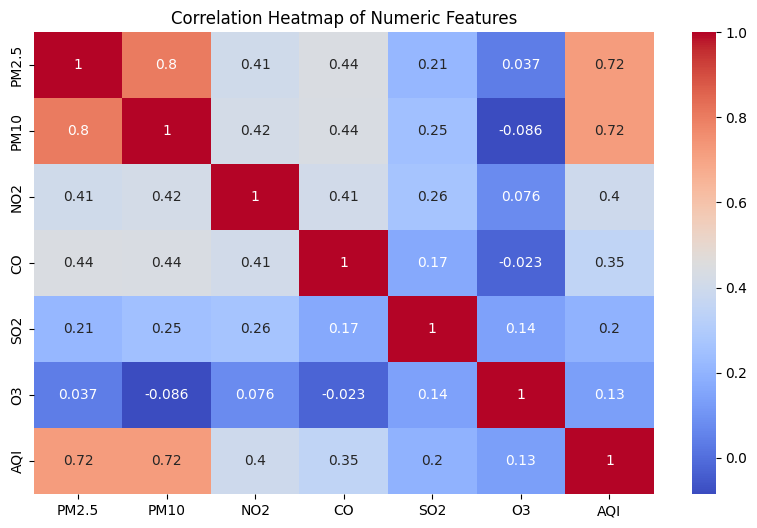

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numerics].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


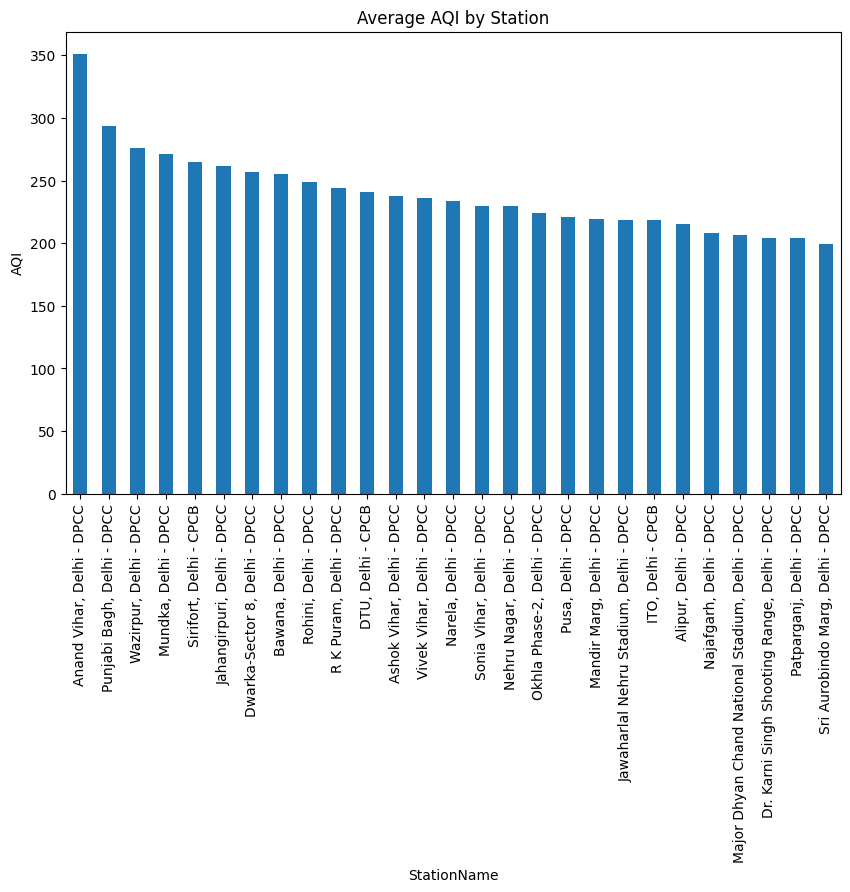

In [ ]:
station_mean = df.groupby('StationName')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
station_mean.plot(kind='bar')
plt.title('Average AQI by Station')
plt.ylabel('AQI')
plt.xticks(rotation=90)
plt.show()


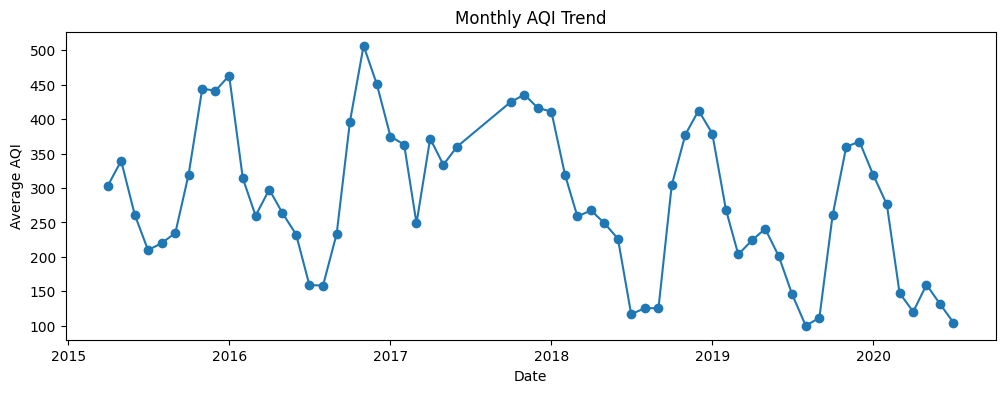

In [ ]:
monthly_aqi = df.groupby(['Year', 'Month'])['AQI'].mean().reset_index()
monthly_aqi['Date'] = pd.to_datetime(monthly_aqi[['Year', 'Month']].assign(day=1))

plt.figure(figsize=(12, 4))
plt.plot(monthly_aqi['Date'], monthly_aqi['AQI'], marker='o')
plt.title("Monthly AQI Trend")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.show()


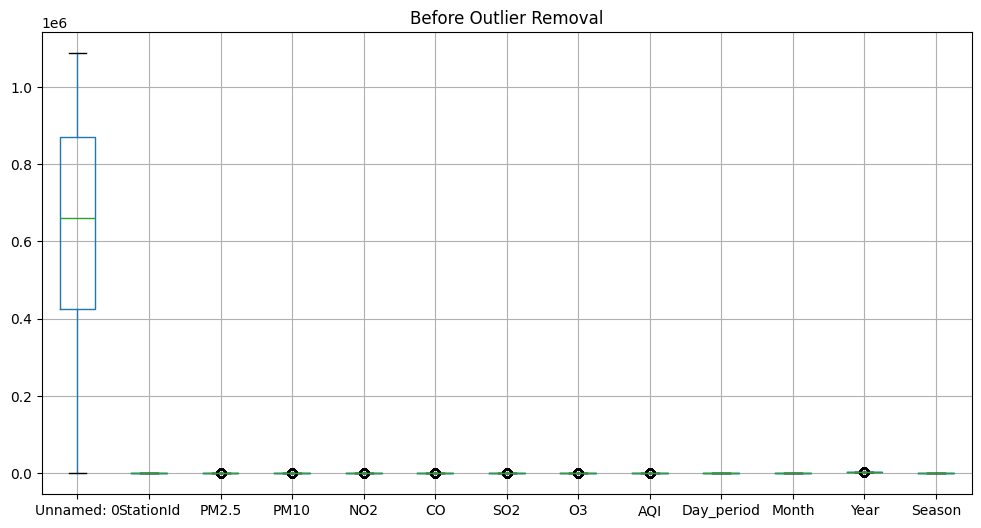

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
df.describe()
df.boxplot(figsize=(12, 6))
plt.title("Before Outlier Removal")
plt.show()


In [ ]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Calculate Z-scores
z_scores = np.abs(zscore(df[numeric_cols]))

# Set threshold
threshold = 3

# Keep only data within threshold
df_clean = df[(z_scores < threshold).all(axis=1)]


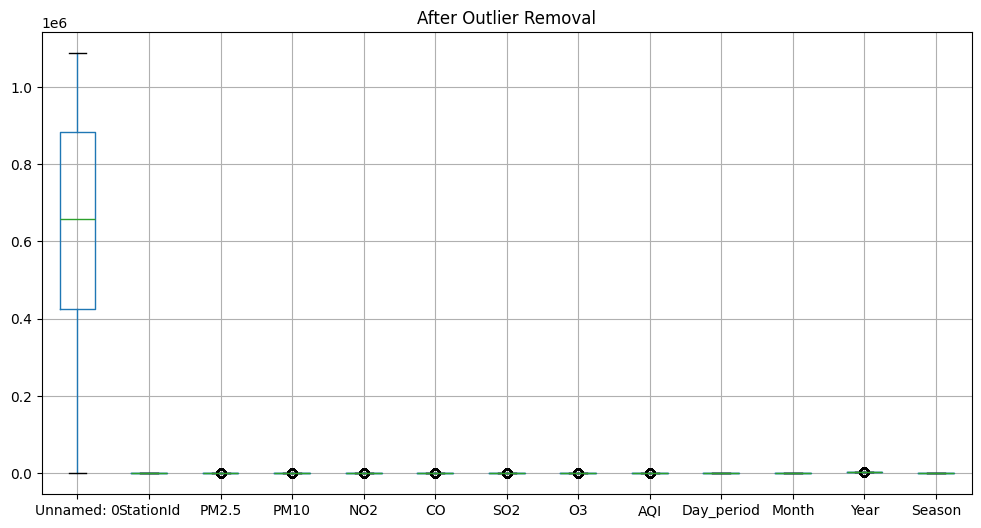

In [ ]:
df_clean.describe()
df_clean.boxplot(figsize=(12, 6))
plt.title("After Outlier Removal")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df_cleaned[numerical_cols])
plt.title("After Removing Outliers with Z-Score")
plt.xticks(rotation=45)
plt.show()


NameError: name 'df_cleaned' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
from scipy.stats import zscore
import numpy as np

# Calculate Z-score only for AQI
z_scores_aqi = np.abs(zscore(df['AQI'], nan_policy='omit'))

# Keep rows where AQI z-score < 3
df_aqi_cleaned = df[z_scores_aqi < 3]



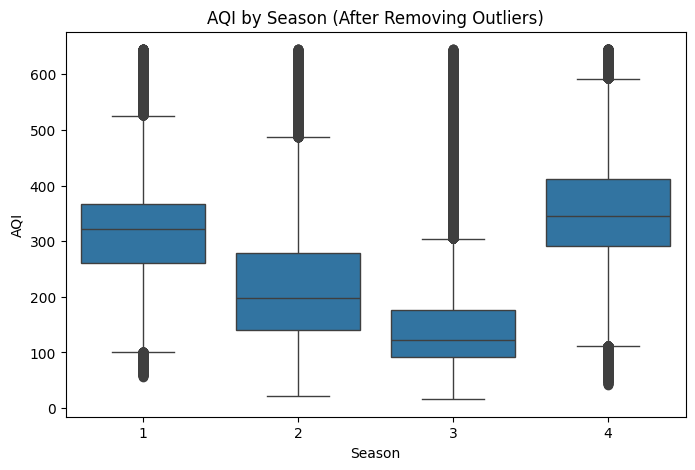

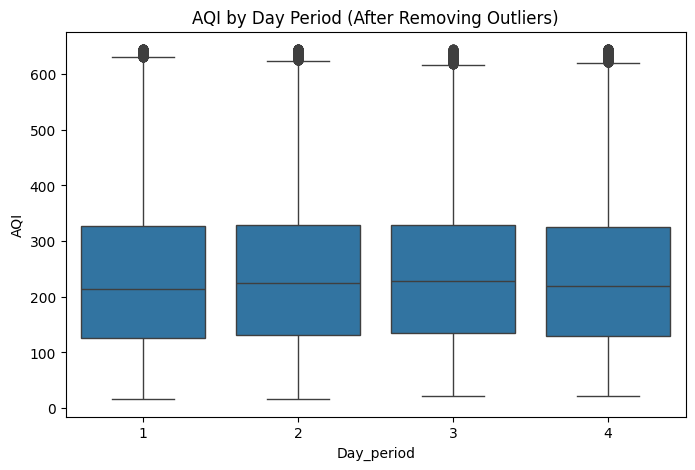

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_aqi_cleaned, x='Season', y='AQI')
plt.title("AQI by Season (After Removing Outliers)")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_aqi_cleaned, x='Day_period', y='AQI')
plt.title("AQI by Day Period (After Removing Outliers)")
plt.show()



Logistic Regression:
Training Accuracy: 0.91
Testing Accuracy: 0.91


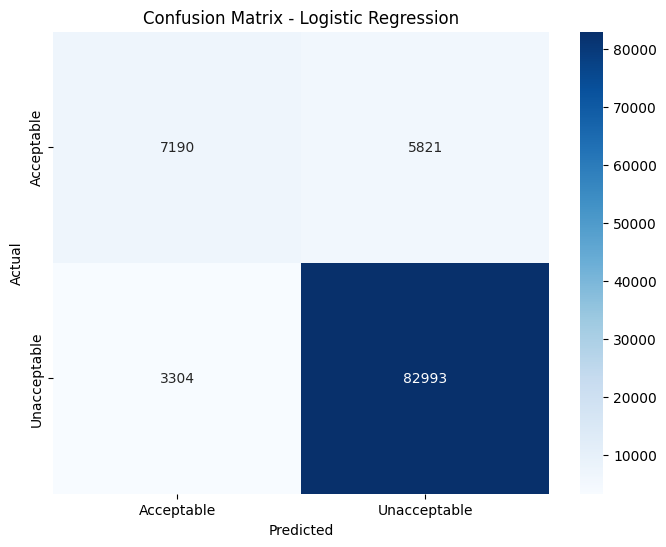

Classification Report:
              precision    recall  f1-score   support

  Acceptable       0.69      0.55      0.61     13011
Unacceptable       0.93      0.96      0.95     86297

    accuracy                           0.91     99308
   macro avg       0.81      0.76      0.78     99308
weighted avg       0.90      0.91      0.90     99308



In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_test_acc = accuracy_score(y_test, lr.predict(X_test_scaled))
accuracies['Logistic Regression'] = (lr_train_acc, lr_test_acc)
print("\nLogistic Regression:")
print(f"Training Accuracy: {lr_train_acc:.2f}")
print(f"Testing Accuracy: {lr_test_acc:.2f}")
# Colored confusion matrix as a heatmap
cm_lr = confusion_matrix(y_test, lr.predict(X_test_scaled))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Classification Report:")
print(classification_report(y_test, lr.predict(X_test_scaled), target_names=le.classes_))

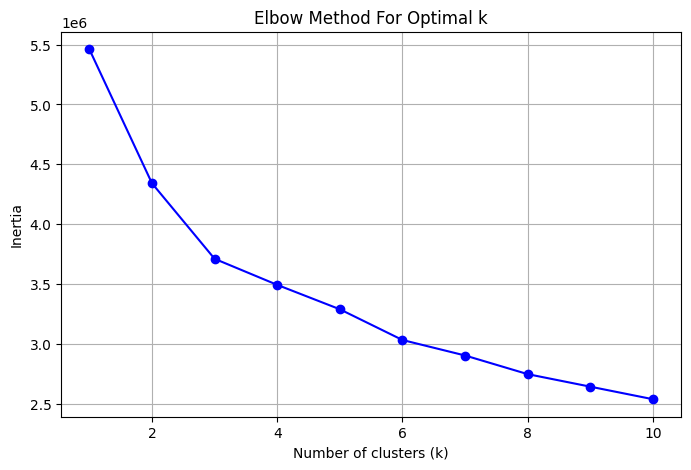

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow Method
inertia = []
k_range = range(1, 11)  # Try k = 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_reg)
X_poly_test = poly.transform(X_test_reg)
poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train_reg)
y_train_pred = poly_reg.predict(X_poly_train)
y_test_pred = poly_reg.predict(X_poly_test)
train_r2 = poly_reg.score(X_poly_train, y_train_reg)
test_r2 = poly_reg.score(X_poly_test, y_test_reg)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))
print(f"Polynomial Regression - Train R²: {train_r2:.4f}")
print(f"Polynomial Regression - Test R²: {test_r2:.4f}")
print(f"Polynomial Regression - Train RMSE: {train_rmse:.4f}")
print(f"Polynomial Regression - Test RMSE: {test_rmse:.4f}")


Polynomial Regression - Train R²: 0.7172
Polynomial Regression - Test R²: 0.7159
Polynomial Regression - Train RMSE: 71.3029
Polynomial Regression - Test RMSE: 71.8007


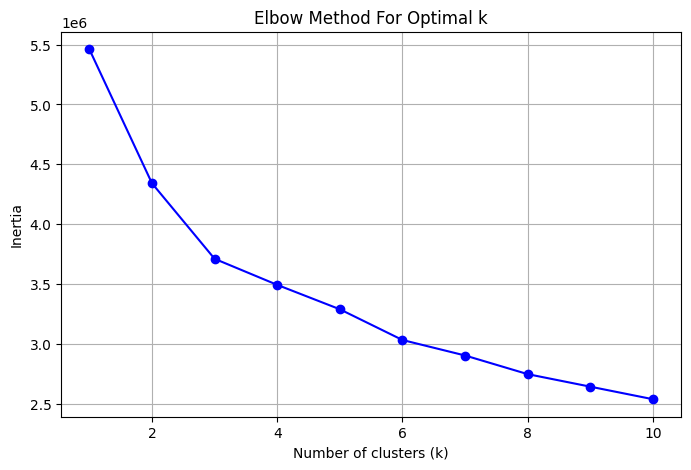

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow Method
inertia = []
k_range = range(1, 11)  # Try k = 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()


In [ ]:
optimal_k = 2  # Replace with your elbow point
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)


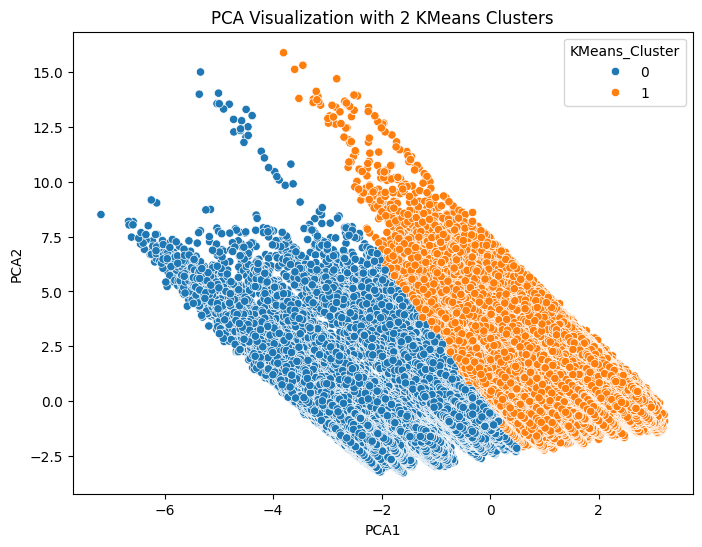

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

# PCA again just to ensure updated visuals
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot with KMeans clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df, palette='tab10')
plt.title(f'PCA Visualization with {optimal_k} KMeans Clusters')
plt.show()


In [ ]:
# 3. Logistic Regression
# -----------------------
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_clf, y_train_clf)
y_pred_log = logreg.predict(X_test_clf)
print("\nLogistic Regression - Accuracy:", accuracy_score(y_test_clf, y_pred_log))
print("Classification Report:\n", classification_report(y_test_clf, y_pred_log))


Logistic Regression - Accuracy: 0.909805856527168
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.57      0.62     12837
           1       0.94      0.96      0.95     86471

    accuracy                           0.91     99308
   macro avg       0.81      0.76      0.78     99308
weighted avg       0.90      0.91      0.91     99308



In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: KMeans with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Step 2: PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Step 3: Visualize PCA with KMeans clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='Set1', data=df)
plt.title('PCA Visualization with KMeans Clusters (k=2)')
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Need to import LabelEncoder as it's used below
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Need pandas for series operations

# Assuming df exists from previous steps and has 'AQ_Acceptability' and relevant features
# Re-create or ensure the data preparation steps leading to X_scaled and y are run before this cell.
# This includes handling missing values, encoding categorical features (including the target 'AQ_Acceptability'),
# and scaling features.

# It seems the X_scaled and y are prepared in a previous cell (ipython-input-12-...).
# We need to ensure that the 'le' used for the target variable 'AQ_Acceptability'
# is correctly associated with the classes present in the original 'AQ_Acceptability' column.

# Let's re-run the data preparation from ipython-input-12 just before this cell
# to ensure X_scaled, y, and le are correctly generated based on the current state of df.

# Assuming df exists and has 'StationName', 'Day_period', 'Season', 'AQ_Acceptability', and numeric columns like PM2.5 etc.
# Drop rows with missing target or required feature columns - Use the same logic as the classification prep cell
# It's crucial that this aligns with how X_scaled and y were created.
df_classification = df.copy() # Create a copy to avoid modifying the original df used for other analysis
df_classification = df_classification.dropna(subset=['AQI', 'AQ_Acceptability', 'StationName', 'Day_period', 'Season'])

label_cols = ['StationName', 'Day_period', 'Season', 'AQ_Acceptability']
label_encoders = {}
le = None # Initialize le to None before the loop
for col in label_cols:
    # Check if column exists before applying LabelEncoder
    if col in df_classification.columns:
        le_temp = LabelEncoder()
        # Fit and transform on the entire relevant data before splitting
        df_classification[col] = le_temp.fit_transform(df_classification[col])
        label_encoders[col] = le_temp
        if col == 'AQ_Acceptability':
            le = le_temp # Keep the label encoder for the target variable
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping encoding.")


# Define features (X) and target (y) for classification
# Ensure 'Datetime', 'AQI_Bucket', and 'AQI' are not used as features for classification
features_for_classification = [col for col in df_classification.columns if col not in ['AQI', 'AQ_Acceptability', 'Datetime', 'AQI_Bucket', 'Month', 'Year', 'Hour']] # Exclude time components and original AQI columns
X = df_classification[features_for_classification]
y = df_classification['AQ_Acceptability']

# Scale features - IMPORTANT: Use the data *after* dropping NaNs for classification
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Now proceed with the split and classification report, using the generated le

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y # Using stratify helps ensure class distribution is similar in train/test
)

# Initialize and train Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

# Predict on training and testing data
y_train_pred = dt.predict(X_train_scaled)
y_test_pred = dt.predict(X_test_scaled)

# Calculate accuracies
dt_train_acc = accuracy_score(y_train, y_train_pred)
dt_test_acc = accuracy_score(y_test, y_test_pred)

# Store accuracies (if using your accuracies dict)
if 'accuracies' not in globals():
    accuracies = {}
accuracies['Decision Tree'] = (dt_train_acc, dt_test_acc)

# Print accuracies side by side
print("\nDecision Tree:")
print(f"Training Accuracy: {dt_train_acc:.4f}")
print(f"Testing Accuracy: {dt_test_acc:.4f}")

# Confusion Matrix with labels from your label encoder 'le'
cm_dt = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
# Use le.classes_ directly here, as le should now correctly reflect the classes seen during encoding
if le is not None and hasattr(le, 'classes_'):
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
else:
     # Fallback if le or its classes_ are not properly defined
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
# Get the unique labels present in y_test
# Use the original class names associated with these labels using the label encoder 'le'
if le is not None and hasattr(le, 'classes_'):
    # Map the numeric labels in y_test to their original names
    # Find the indices of the unique labels in y_test within the original classes of 'le'
    unique_test_labels = sorted(y_test.unique())
    # Ensure that unique_test_labels are valid indices for le.classes_
    if all(label in range(len(le.classes_)) for label in unique_test_labels):
        target_names_subset = [le.classes_[label] for label in unique_test_labels]
        print(classification_report(y_test, y_test_pred, labels=unique_test_labels, target_names=target_names_subset))
    else:
        # Fallback if unique_test_labels do not correspond to valid indices
         print("Warning: Could not map y_test labels to original class names. Printing report with numeric labels.")
         print(classification_report(y_test, y_test_pred))
else:
     print("Warning: LabelEncoder 'le' not properly initialized or has no classes_. Printing report with numeric labels.")
     print(classification_report(y_test, y_test_pred))

NameError: name 'df' is not defined

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_clf, y_train_clf)
y_pred_rf = rf_model.predict(X_test_clf)

print("🔷 Random Forest Classifier 🔷")
print("Confusion Matrix:\n", confusion_matrix(y_test_clf, y_pred_rf))
print("Accuracy Score:", accuracy_score(y_test_clf, y_pred_rf))
print("Precision Score:", precision_score(y_test_clf, y_pred_rf, average='macro'))
print("Recall Score:", recall_score(y_test_clf, y_pred_rf, average='macro'))
print("F1 Score:", f1_score(y_test_clf, y_pred_rf, average='macro'))
print("Classification Report:\n", classification_report(y_test_clf, y_pred_rf))


🔷 Random Forest Classifier 🔷
Confusion Matrix:
 [[10116  2721]
 [ 2116 84355]]
Accuracy Score: 0.9512929471945866
Precision Score: 0.8978812769528051
Recall Score: 0.8817819778739735
F1 Score: 0.8895905613241181
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81     12837
           1       0.97      0.98      0.97     86471

    accuracy                           0.95     99308
   macro avg       0.90      0.88      0.89     99308
weighted avg       0.95      0.95      0.95     99308




KNN:
Training Accuracy: 0.96
Testing Accuracy: 0.93


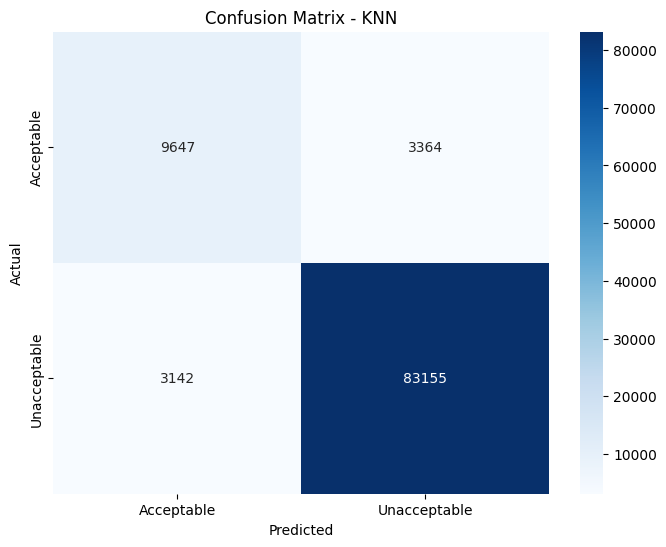

Classification Report:
              precision    recall  f1-score   support

  Acceptable       0.75      0.74      0.75     13011
Unacceptable       0.96      0.96      0.96     86297

    accuracy                           0.93     99308
   macro avg       0.86      0.85      0.86     99308
weighted avg       0.93      0.93      0.93     99308



In [ ]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
knn_test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))
accuracies['KNN'] = (knn_train_acc, knn_test_acc)
print("\nKNN:")
print(f"Training Accuracy: {knn_train_acc:.2f}")
print(f"Testing Accuracy: {knn_test_acc:.2f}")
# Colored confusion matrix as a heatmap
cm_knn = confusion_matrix(y_test, knn.predict(X_test_scaled))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Classification Report:")
print(classification_report(y_test, knn.predict(X_test_scaled), target_names=le.classes_))


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train_scaled, y_train, X_test_scaled, y_test, and 'le' LabelEncoder are defined

# Train SVM model
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_scaled, y_train)

# Evaluate SVM
y_test_pred = svm.predict(X_test_scaled)

# Calculate accuracy
svm_train_acc = svm.score(X_train_scaled, y_train)
svm_test_acc = svm.score(X_test_scaled, y_test)

# Classes in test set
unique_classes_in_test = np.unique(y_test)

print("\nSVM:")
print(f"Training Accuracy: {svm_train_acc:.2f}")
print(f"Testing Accuracy: {svm_test_acc:.2f}")

# Confusion matrix plot
cm_svm = confusion_matrix(y_test, y_test_pred, labels=unique_classes_in_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.inverse_transform(unique_classes_in_test),
            yticklabels=le.inverse_transform(unique_classes_in_test))
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred,
                            labels=unique_classes_in_test,
                            target_names=le.inverse_transform(unique_classes_in_test)))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA
import gc



# Select numerical features for clustering
numerical_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']

# Step 2: Preprocessing
# Handle missing values by imputing with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Aggregate by StationName (27 unique stations) to reduce dataset size
df_agg = df.groupby('StationName')[numerical_cols].mean().reset_index()
X = df_agg[numerical_cols].values

# Step 3: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clear memory
gc.collect()

# Step 4: Hierarchical Clustering (linkage matrix)
linked = linkage(X_scaled, method='ward')  # 'ward' linkage for minimizing variance

# Step 5: Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           labels=df_agg['StationName'].values,  # Label with station names
           show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram (Delhi Air Quality - 27 Stations)")
plt.xlabel("Station Name")
plt.ylabel("Distance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("dendrogram_air_quality_stations.png")  # Save for report
plt.close()  # Close plot to free memory
gc.collect()

# Step 6: Cut the dendrogram at 3 clusters
clusters = fcluster(linked, t=3, criterion='maxclust')

# Step 7: Visualize clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='rainbow')
plt.title("Hierarchical Clustering of Air Quality Data (PCA, 27 Stations)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
# Add station names as annotations
for i, station in enumerate(df_agg['StationName']):
    plt.annotate(station, (X_pca[i, 0], X_pca[i, 1]), fontsize=8)
plt.colorbar(scatter, label='Cluster')
plt.savefig("pca_clusters_air_quality_stations.png")  # Save for report
plt.close()  # Close plot to free memory
gc.collect()

NameError: name 'df' is not defined

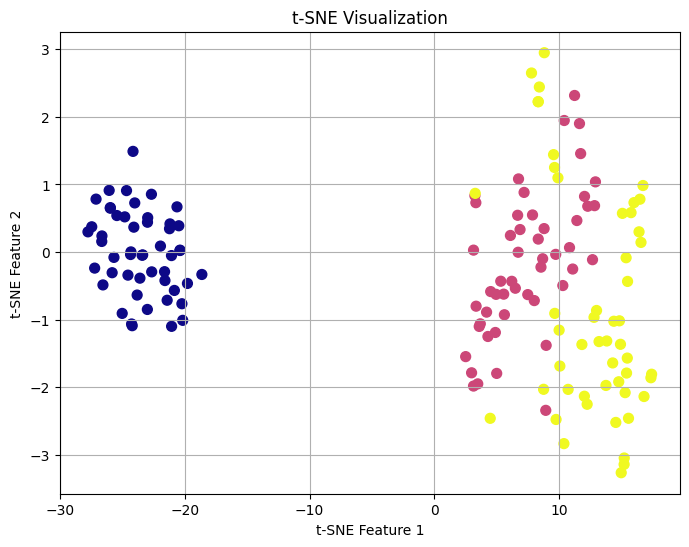

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Step 1: Load dataset (you can replace this with your own)
data = load_iris()
X = data.data
y = data.target  # true labels (optional, can be replaced with cluster labels)

# Step 2: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Step 4: Plot t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='plasma', s=50)
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.grid(True)
plt.show()


In [ ]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC # Import SVC here
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Assuming df is already loaded and preprocessed from previous steps
# If not, you need to load and preprocess it here, including handling missing values

# For demonstration, let's assume df exists and has 'AQI', 'AQ_Acceptability'
# And the necessary features from previous cells like 'StationName', 'Day_period', 'Season'
# We will recreate the relevant parts of the preprocessing for clarity.

# This part should align with how the data was prepared for the other classifiers
# Drop rows with missing target or label columns
df = df.dropna(subset=['AQI', 'AQ_Acceptability', 'StationName', 'Day_period', 'Season'])

label_cols = ['StationName', 'Day_period', 'Season', 'AQ_Acceptability']
label_encoders = {}
le = None # Initialize le to None
for col in label_cols:
    le_temp = LabelEncoder()
    df[col] = le_temp.fit_transform(df[col])
    label_encoders[col] = le_temp
    if col == 'AQ_Acceptability':
        le = le_temp # Keep the label encoder for the target variable

# Define features (X) and target (y) for classification
# Ensure 'Datetime', 'AQI_Bucket', and 'AQI' are not used as features for classification
features_for_classification = [col for col in df.columns if col not in ['AQI', 'AQ_Acceptability', 'Datetime', 'AQI_Bucket']]
X = df[features_for_classification]
y = df['AQ_Acceptability']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data for classification
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize accuracies dictionary (assuming it was used elsewhere to store results)
accuracies = {}

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_scaled, y_train)
svm_train_acc = accuracy_score(y_train, svm.predict(X_train_scaled))
svm_test_acc = accuracy_score(y_test, svm.predict(X_test_scaled))
accuracies['SVM'] = (svm_train_acc, svm_test_acc)
print("\nSVM:")
print(f"Training Accuracy: {svm_train_acc:.2f}")
print(f"Testing Accuracy: {svm_test_acc:.2f}")

# Colored confusion matrix as a heatmap
cm_svm = confusion_matrix(y_test, svm.predict(X_test_scaled))
plt.figure(figsize=(8, 6))
# Ensure le is defined and has the classes attribute
if le is not None and hasattr(le, 'classes_'):
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
else:
    # Fallback if le or its classes_ are not properly defined (shouldn't happen if the above code runs)
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
# Ensure le is defined and has the classes attribute
if le is not None and hasattr(le, 'classes_'):
    print(classification_report(y_test, svm.predict(X_test_scaled), target_names=le.classes_))
else:
     print(classification_report(y_test, svm.predict(X_test_scaled))) # Fallback

🔷 Linear Regression Results
Train MSE: 7010.96, R²: 0.6101
Test  MSE: 7090.38, R²: 0.6093


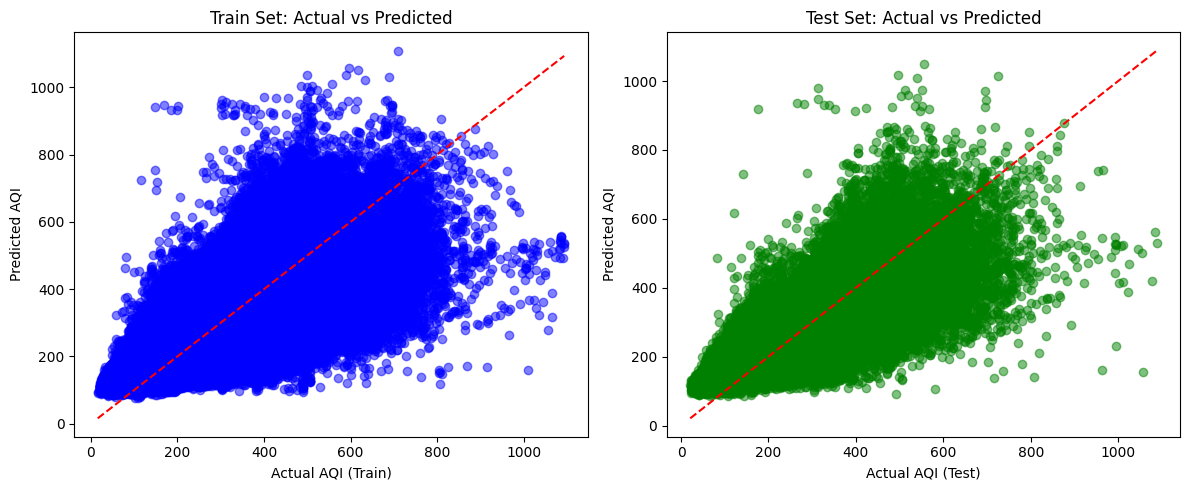

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------
# Prepare Data for Regression
# ------------------------
df_reg = df.copy()
df_reg = df_reg.dropna(subset=['AQI', 'StationName', 'Day_period', 'Season'])

# Encode categorical variables
label_cols_reg = ['StationName', 'Day_period', 'Season']
for col in label_cols_reg:
    le = LabelEncoder()
    df_reg[col] = le.fit_transform(df_reg[col])

# Define features and target for regression
X_reg = df_reg.drop(columns=['AQI', 'AQ_Acceptability', 'Datetime', 'AQI_Bucket', 'Month', 'Year', 'Hour'], errors='ignore')
y_reg = df_reg['AQI']

# Scale features
scaler_reg = StandardScaler()
X_scaled_reg = scaler_reg.fit_transform(X_reg)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled_reg, y_reg, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
y_pred_train = lr.predict(X_train_reg)
y_pred_test = lr.predict(X_test_reg)
train_mse = mean_squared_error(y_train_reg, y_pred_train)
test_mse = mean_squared_error(y_test_reg, y_pred_test)
train_r2 = r2_score(y_train_reg, y_pred_train)
test_r2 = r2_score(y_test_reg, y_pred_test)
print("🔷 Linear Regression Results")
print(f"Train MSE: {train_mse:.2f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.2f}, R²: {test_r2:.4f}")
plt.figure(figsize=(12, 5))
# Train vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_train_reg, y_pred_train, alpha=0.5, color='blue')
plt.plot([y_train_reg.min(), y_train_reg.max()], [y_train_reg.min(), y_train_reg.max()], 'r--')
plt.xlabel('Actual AQI (Train)')
plt.ylabel('Predicted AQI')
plt.title('Train Set: Actual vs Predicted')
# Test vs Actual
plt.subplot(1, 2, 2)
plt.scatter(y_test_reg, y_pred_test, alpha=0.5, color='green')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual AQI (Test)')
plt.ylabel('Predicted AQI')
plt.title('Test Set: Actual vs Predicted')
plt.tight_layout()
plt.show()


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Assuming df is already loaded and cleaned


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=np.number))


In [ ]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.axhline(y=20, color='red', linestyle='--')  # You can adjust this value to where clear clusters separate
plt.title('Dendrogram to Determine Optimal Clusters (k)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()
